## 1. Imports & Configuration

In [ ]:
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_squared_error, mean_absolute_percentage_error
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Config ───────────────────────────────────────────────────────────────────
CENTER_ID      = 13          # fulfillment center to model
TRAIN_WEEK_CUT = 110         # weeks <= this go to train, rest to test
DATA_PATH      = 'train_merged.csv'
ENCODER_PATH   = 'encoder.pkl'
MODEL_PATH     = 'xgb_food_demand_center13.pkl'

print("✅ Libraries loaded successfully")
print(f"   Target center : {CENTER_ID}")
print(f"   Train/test cut: week {TRAIN_WEEK_CUT}")


✅ Libraries loaded successfully
   Target center : 13
   Train/test cut: week 110


## 2. Data Loading & Basic Quality Check

In [ ]:
df = pd.read_csv('train_merged.csv')

print(f"Shape          : {df.shape}")
print(f"Columns        : {list(df.columns)}")
print(f"\nDate range (week): {df['week'].min()} → {df['week'].max()}")
print(f"Unique centers : {df['center_id'].nunique()}")
print(f"Unique meals   : {df['meal_id'].nunique()}")


Shape          : (456548, 15)
Columns        : ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'city_code', 'region_code', 'center_type', 'op_area', 'category', 'cuisine']

Date range (week): 1 → 145
Unique centers : 77
Unique meals   : 51


In [ ]:
# ── Quality Checks ───────────────────────────────────────────────────────────
print("=" * 45)
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"\nNull values:")
print(df.isnull().sum())
print("=" * 45)

df.head()


Duplicate rows : 0

Null values:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.00,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.00,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.00,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.00,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.00,Beverages,Indian


In [ ]:
df.describe()


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00
mean,1250096.31,74.77,82.11,2024.34,332.24,354.16,0.08,0.11,261.87,601.55,56.61,4.08
std,144354.82,41.52,45.98,547.42,152.94,160.72,0.27,0.31,395.92,66.20,17.64,1.09
min,1000000.00,1.00,10.00,1062.00,2.97,55.35,0.00,0.00,13.00,456.00,23.00,0.90
25%,1124998.75,39.00,43.00,1558.00,228.95,243.50,0.00,0.00,54.00,553.00,34.00,3.60
50%,1250183.50,76.00,76.00,1993.00,296.82,310.46,0.00,0.00,136.00,596.00,56.00,4.00
75%,1375140.25,111.00,110.00,2539.00,445.23,458.87,0.00,0.00,324.00,651.00,77.00,4.50
max,1499999.00,145.00,186.00,2956.00,866.27,866.27,1.00,1.00,24299.00,713.00,93.00,7.00


## 3. Exploratory Data Analysis (EDA)

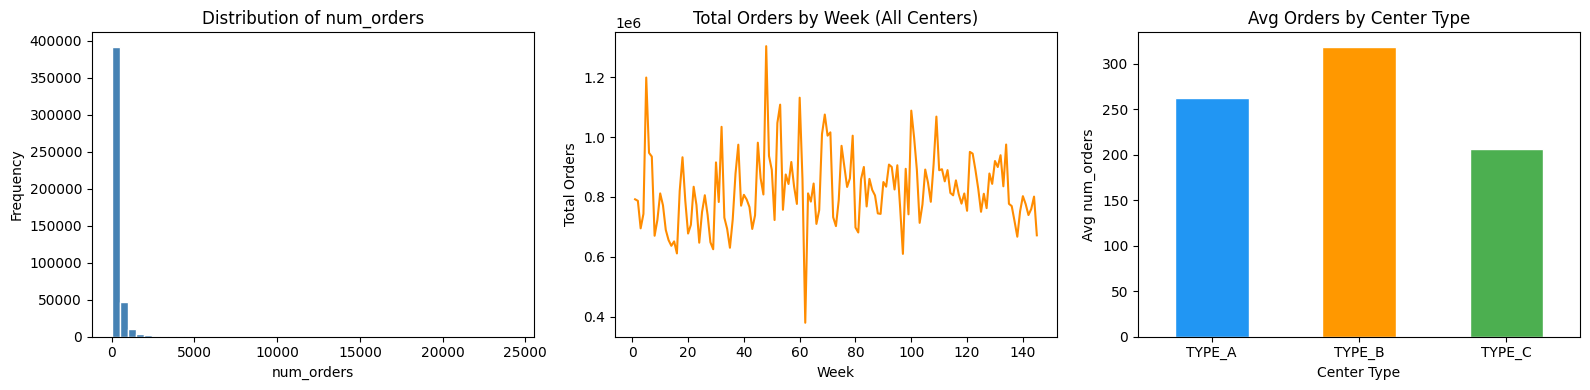

💡 Insight: Check for seasonal/weekly trends in the middle chart above.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
axes[0].hist(df['num_orders'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of num_orders')
axes[0].set_xlabel('num_orders')
axes[0].set_ylabel('Frequency')

# Orders over time (global trend)
weekly = df.groupby('week')['num_orders'].sum().reset_index()
axes[1].plot(weekly['week'], weekly['num_orders'], color='darkorange', linewidth=1.5)
axes[1].set_title('Total Orders by Week (All Centers)')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Total Orders')

# Orders by center type
df.groupby('center_type')['num_orders'].mean().plot(
    kind='bar', ax=axes[2], color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white'
)
axes[2].set_title('Avg Orders by Center Type')
axes[2].set_xlabel('Center Type')
axes[2].set_ylabel('Avg num_orders')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Insight: Check for seasonal/weekly trends in the middle chart above.")


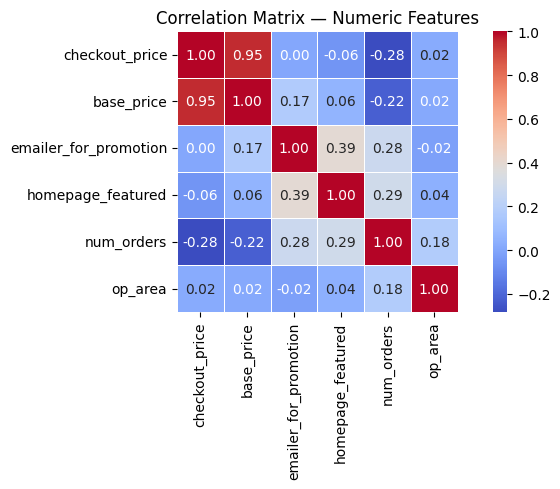

In [ ]:
# ── Correlation heatmap for numeric cols ─────────────────────────────────────
num_cols = ['checkout_price', 'base_price', 'emailer_for_promotion',
            'homepage_featured', 'num_orders', 'op_area']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Feature Engineering

**New features created:**
| Feature | Logic | Rationale |
|---|---|---|
| `discount` | `base_price - checkout_price` | Absolute discount amount |
| `discount_per` | `(discount / base_price) * 100` | Relative discount % |
| `discount_bin` | Binned `discount_per` | Captures non-linear discount effect |
| `price_band` | Binned `checkout_price` | Price sensitivity segmentation |


In [ ]:
# ── Discount features ────────────────────────────────────────────────────────
df['discount'] = (df['base_price'] - df['checkout_price']).round(2)

df['discount_per'] = (
    ((df['base_price'] - df['checkout_price']) / df['base_price']) * 100
).round(2)

# Clip negative discounts to 0 (data quality fix)
negative_disc_count = (df['discount_per'] < 0).sum()
df['discount_per'] = df['discount_per'].clip(lower=0)
print(f"⚠️  Clipped {negative_disc_count} rows with negative discount_per to 0")

# ── Discount bins ─────────────────────────────────────────────────────────────
disc_bins   = [-0.01, 0, 5, 10, 20, 30, 40, 50, 100]
disc_labels = ['0', '0-5', '5-10', '10-20', '20-30', '30-40', '40-50', '50-100']
df['discount_bin'] = pd.cut(df['discount_per'], bins=disc_bins,
                            labels=disc_labels, include_lowest=True)

# ── Price band ────────────────────────────────────────────────────────────────
price_bins   = [0, 100, 150, 200, 250, 300, 400, 600, np.inf]
price_labels = ['<=100', '101-150', '151-200', '201-250',
                '251-300', '301-400', '401-600', '600+']
df['price_band'] = pd.cut(df['checkout_price'], bins=price_bins,
                          labels=price_labels, include_lowest=True)

print("\n✅ Feature engineering complete")
print(df[['base_price', 'checkout_price', 'discount', 'discount_per',
          'discount_bin', 'price_band']].head())


⚠️  Clipped 116100 rows with negative discount_per to 0

✅ Feature engineering complete
   base_price  checkout_price  discount  discount_per discount_bin price_band
0      152.29          136.83     15.46         10.15        10-20    101-150
1      135.83          136.83     -1.00          0.00            0    101-150
2      135.86          134.86      1.00          0.74          0-5    101-150
3      437.53          339.50     98.03         22.41        20-30    301-400
4      242.50          243.50     -1.00          0.00            0    201-250


## 5. Categorical Encoding (OneHotEncoder)

In [ ]:
cat_col = ['center_type', 'category', 'cuisine', 'discount_bin', 'price_band']

encoder = OneHotEncoder(
    sparse_output=False,   # return dense array
    handle_unknown='ignore' # silently ignore unseen categories at inference
)

encoder.fit(df[cat_col])
encoded     = encoder.transform(df[cat_col])
encoded_df  = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_col))

# Merge back
df = pd.concat([df.drop(columns=cat_col).reset_index(drop=True), encoded_df], axis=1)

# Persist encoder for inference/deployment
joblib.dump(encoder, ENCODER_PATH)

print(f"✅ Encoder saved → {ENCODER_PATH}")
print(f"   Encoded features added : {encoded_df.shape[1]}")
print(f"   Final dataframe shape  : {df.shape}")


✅ Encoder saved → encoder.pkl
   Encoded features added : 37
   Final dataframe shape  : (456548, 51)


## 6. Filter Data — Center ID 13

In [ ]:
center_df = df[df['center_id'] == CENTER_ID].copy()
center_df = center_df.sort_values(['meal_id', 'week']).reset_index(drop=True)

print(f"Rows for center {CENTER_ID}  : {len(center_df)}")
print(f"Unique meals in center       : {center_df['meal_id'].nunique()}")
print(f"Week range                  : {center_df['week'].min()} → {center_df['week'].max()}")


Rows for center 13  : 7046
Unique meals in center       : 51
Week range                  : 1 → 145


In [ ]:
# ── Select relevant columns ───────────────────────────────────────────────────
base_cols = [
    'week', 'meal_id', 'emailer_for_promotion', 'homepage_featured',
    'num_orders', 'op_area', 'discount_per'
]

ohe_cols = [c for c in center_df.columns if c.startswith(('center_type_',
            'category_', 'cuisine_', 'discount_bin_', 'price_band_'))]

# Sanitize column names for XGBoost (no special chars)
center_df.columns = (
    center_df.columns.astype(str)
    .str.replace(r'[^a-zA-Z0-9_]', '', regex=True)
)

# Re-identify ohe_cols after sanitization
ohe_cols_clean = [c for c in center_df.columns if c.startswith(('center_type_',
                  'category_', 'cuisine_', 'discount_bin_', 'price_band_'))]

selected_cols = base_cols + ohe_cols_clean
# Sanitize base_col names too (price_band has <=)
selected_cols_clean = [
    re.sub(r'[^a-zA-Z0-9_]', '', c) for c in selected_cols
]
center_df = center_df[[c for c in selected_cols_clean if c in center_df.columns]]

print(f"✅ Final columns selected : {center_df.shape[1]}")


✅ Final columns selected : 44


## 7. Time-Series Lag & Rolling Features

**Why lag features?** XGBoost doesn't natively understand time order.  
We manually encode temporal signal by lagging `num_orders`:

| Feature | Meaning |
|---|---|
| `lag_1` | Orders from 1 week ago |
| `lag_2` | Orders from 2 weeks ago |
| `lag_3` | Orders from 3 weeks ago |
| `lag_7` | Orders from 7 weeks ago (monthly seasonal) |
| `rolling_mean_7` | 7-week rolling average (smoothed trend) |
| `rolling_std_7` | 7-week rolling std (demand volatility) |


In [ ]:
grp = center_df.groupby('meal_id')['num_orders']

center_df['lag_1'] = grp.shift(1)
center_df['lag_2'] = grp.shift(2)
center_df['lag_3'] = grp.shift(3)
center_df['lag_7'] = grp.shift(7)

center_df['rolling_mean_7'] = grp.transform(lambda x: x.shift(1).rolling(7).mean())
center_df['rolling_std_7']  = grp.transform(lambda x: x.shift(1).rolling(7).std())

rows_before = len(center_df)
center_df.dropna(inplace=True)
center_df.reset_index(drop=True, inplace=True)
rows_after = len(center_df)

print(f"✅ Lag features created")
print(f"   Rows dropped (NaN from lag) : {rows_before - rows_after}")
print(f"   Remaining rows              : {rows_after}")
center_df[['meal_id', 'week', 'num_orders', 'lag_1', 'lag_2', 'lag_3', 'lag_7',
           'rolling_mean_7', 'rolling_std_7']].head(8)


✅ Lag features created
   Rows dropped (NaN from lag) : 357
   Remaining rows              : 6332


,meal_id,week,num_orders,lag_1,lag_2,lag_3,lag_7,rolling_mean_7,rolling_std_7
0,1062,15,878,701.00,771.00,971.00,1228.00,1136.14,347.66
1,1062,16,906,878.00,701.00,771.00,1459.00,1086.14,357.28
2,1062,17,1581,906.00,878.00,701.00,1176.00,1007.14,320.32
3,1062,18,1270,1581.00,906.00,878.00,1647.00,1065.00,385.79
4,1062,19,1446,1270.00,1581.00,906.00,971.00,1011.14,309.84
5,1062,20,1607,1446.00,1270.00,1581.00,771.00,1079.00,349.11
6,1062,21,1526,1607.00,1446.00,1270.00,701.00,1198.43,368.63
7,1062,22,1430,1526.00,1607.00,1446.00,878.00,1316.29,310.37


## 8. Train / Test Split (Temporal)

In [ ]:
# ── Temporal split — NO shuffling for time-series data ───────────────────────
train = center_df[center_df['week'] <= TRAIN_WEEK_CUT]
test  = center_df[center_df['week'] >  TRAIN_WEEK_CUT]

feature_cols = [c for c in center_df.columns if c != 'num_orders']

X_train = train[feature_cols]
X_test  = test[feature_cols]
y_train = train['num_orders']
y_test  = test['num_orders']

print(f"Train : {len(train)} rows | weeks {train['week'].min()} → {train['week'].max()}")
print(f"Test  : {len(test)} rows  | weeks {test['week'].min()} → {test['week'].max()}")
print(f"Features : {X_train.shape[1]}")


Train : 4566 rows | weeks 15 → 110
Test  : 1766 rows  | weeks 111 → 145
Features : 49


## 9. XGBoost Model Training

**Hyperparameters** were pre-tuned via `RandomizedSearchCV` with `TimeSeriesSplit` in v1.  
Applied directly here to avoid data leakage during search.

| Param | Value | Effect |
|---|---|---|
| `n_estimators` | 400 | Number of trees |
| `learning_rate` | 0.05 | Shrinkage — prevents overfitting |
| `max_depth` | 3 | Shallow trees → bias toward simple patterns |
| `subsample` | 0.6 | Row sampling per tree |
| `colsample_bytree` | 1.0 | All features used per tree |
| `gamma` | 0.5 | Min loss reduction to split — regularization |
| `reg_alpha` | 1 | L1 regularization |
| `reg_lambda` | 1 | L2 regularization |


In [ ]:
model = XGBRegressor(
    n_estimators    = 400,
    learning_rate   = 0.05,
    max_depth       = 3,
    subsample       = 0.6,
    colsample_bytree= 1.0,
    gamma           = 0.5,
    reg_alpha       = 1,
    reg_lambda      = 1,
    random_state    = RANDOM_STATE,
    n_jobs          = -1,
    verbosity       = 0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Save model artifact
joblib.dump(model, MODEL_PATH)
print(f"✅ Model trained & saved → {MODEL_PATH}")


✅ Model trained & saved → xgb_food_demand_center13.pkl


## 10. Model Evaluation

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.maximum(y_pred, 0)   # orders can't be negative

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("=" * 40)
print("  📊 Model Performance — Test Set")
print("=" * 40)
print(f"  R²   : {r2:.4f}   (1.0 = perfect)")
print(f"  MAE  : {mae:.2f}  (avg absolute error in orders)")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

if r2 >= 0.80:
    print("  ✅ Model meets the R² ≥ 0.80 production threshold")
else:
    print("  ⚠️  Model below R² = 0.80 — consider more feature engineering")


  📊 Model Performance — Test Set
  R²   : 0.8490   (1.0 = perfect)
  MAE  : 143.05  (avg absolute error in orders)
  RMSE : 295.97
  MAPE : 43.54%
  ✅ Model meets the R² ≥ 0.80 production threshold


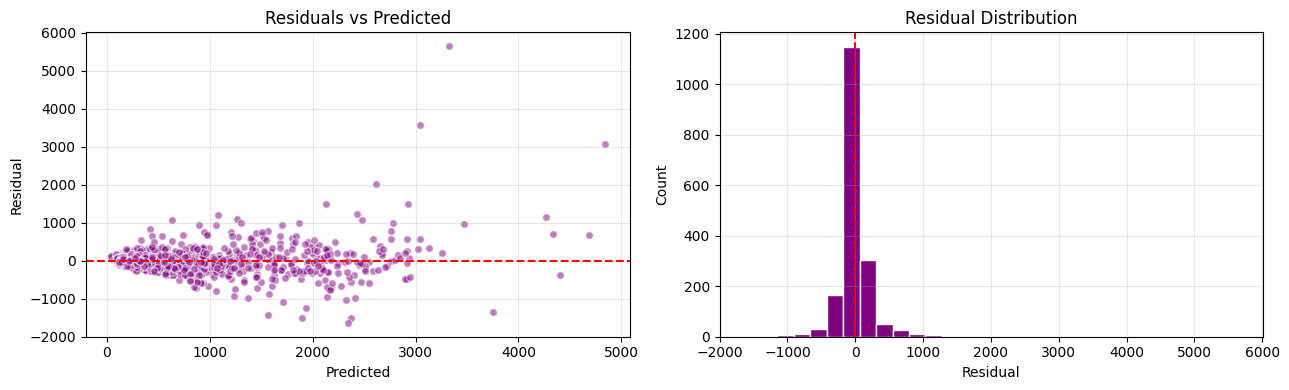

Mean residual : -4.09  (close to 0 = unbiased)
Std  residual : 295.94


In [ ]:
# ── Residual analysis ─────────────────────────────────────────────────────────
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred, residuals, alpha=0.5, color='purple', s=30, edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=30, color='purple', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Mean residual : {residuals.mean():.2f}  (close to 0 = unbiased)")
print(f"Std  residual : {residuals.std():.2f}")


## 11. Feature Importance

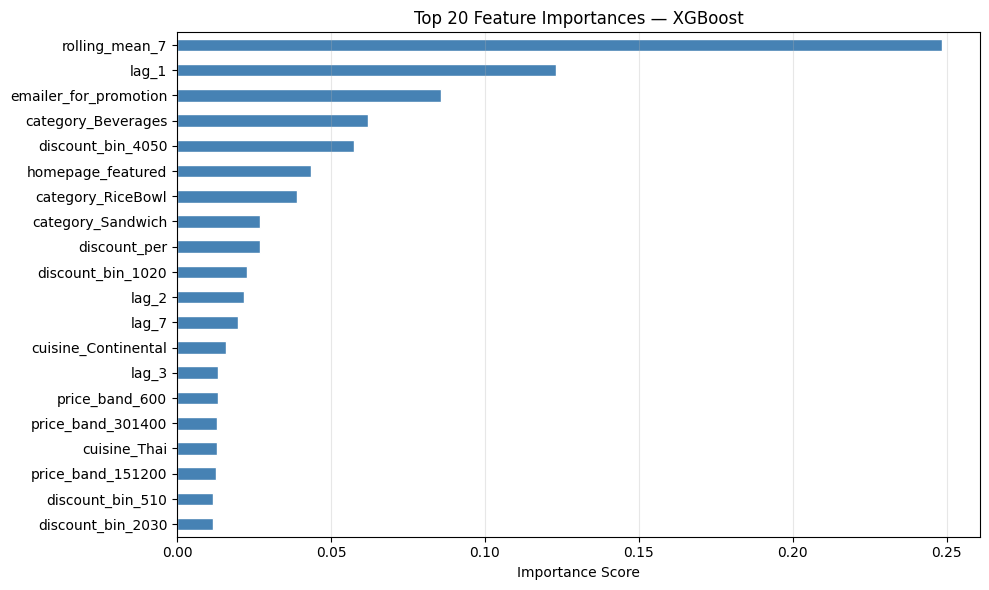

Top 5 most important features:
  rolling_mean_7                      0.2484
  lag_1                               0.1232
  emailer_for_promotion               0.0859
  category_Beverages                  0.0620
  discount_bin_4050                   0.0576


In [ ]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for feat, score in feat_imp.head(5).items():
    print(f"  {feat:<35} {score:.4f}")


## 12. Recursive Future-Week Forecasting

Forecast `N` weeks beyond the dataset using recursive prediction:  
each predicted value is fed back as a lag feature for the next step.


In [ ]:
def recursive_forecast(model, center_df, meal_id, n_future_weeks=8):
    """
    Recursively forecast n_future_weeks ahead for a given meal_id.
    
    Parameters
    ----------
    model        : trained XGBRegressor
    center_df    : preprocessed dataframe (center-filtered, with lags)
    meal_id      : int — which meal to forecast
    n_future_weeks : int — how many weeks ahead

    Returns
    -------
    pd.DataFrame with columns ['week', 'meal_id', 'predicted_orders']
    """
    meal_df = center_df[center_df['meal_id'] == meal_id].copy()
    meal_df = meal_df.sort_values('week').reset_index(drop=True)
    
    history = meal_df['num_orders'].tolist()
    last_week = meal_df['week'].max()
    
    # Take the last row as template for static features
    last_row = meal_df.iloc[-1].copy()
    
    predictions = []
    
    for i in range(1, n_future_weeks + 1):
        # Build lag features from history
        last_row['lag_1'] = history[-1]  if len(history) >= 1 else np.nan
        last_row['lag_2'] = history[-2]  if len(history) >= 2 else np.nan
        last_row['lag_3'] = history[-3]  if len(history) >= 3 else np.nan
        last_row['lag_7'] = history[-7]  if len(history) >= 7 else np.nan
        last_row['rolling_mean_7'] = np.mean(history[-7:]) if len(history) >= 7 else np.mean(history)
        last_row['rolling_std_7']  = np.std(history[-7:])  if len(history) >= 7 else np.std(history)
        last_row['week'] = last_week + i
        
        X_future = last_row[model.feature_names_in_].values.reshape(1, -1)
        pred = float(model.predict(X_future)[0])
        pred = max(0, round(pred))   # clip negatives, round to int
        
        predictions.append({'week': last_week + i, 'meal_id': meal_id, 'predicted_orders': pred})
        history.append(pred)   # feed prediction back
    
    return pd.DataFrame(predictions)


# ── Run forecast for all meals in center ─────────────────────────────────────
N_FUTURE = 8
all_forecasts = []

for mid in center_df['meal_id'].unique():
    try:
        fc = recursive_forecast(model, center_df, mid, N_FUTURE)
        all_forecasts.append(fc)
    except Exception as e:
        print(f"⚠️  meal_id {mid} skipped: {e}")

forecast_df = pd.concat(all_forecasts, ignore_index=True)

print(f"✅ Forecasted {N_FUTURE} weeks for {forecast_df['meal_id'].nunique()} meals")
print(f"   Future weeks: {forecast_df['week'].min()} → {forecast_df['week'].max()}")
forecast_df.head(10)


✅ Forecasted 8 weeks for 51 meals
   Future weeks: 146 → 153


,week,meal_id,predicted_orders
0,146,1062,991
1,147,1062,1002
2,148,1062,1076
3,149,1062,1071
4,150,1062,1066
5,151,1062,1036
6,152,1062,1076
7,153,1062,1098
8,146,1109,1795
9,147,1109,1737


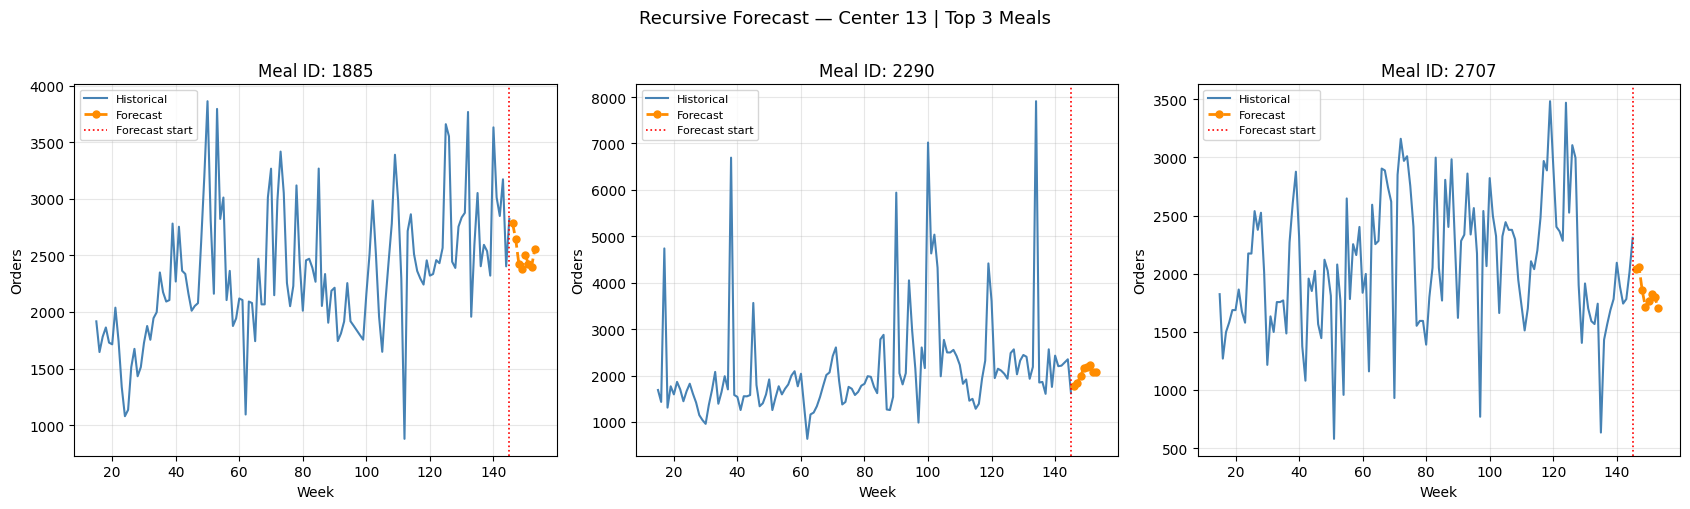

In [ ]:
# ── Plot forecast for top 3 meals by average orders ───────────────────────────
top_meals = (
    center_df.groupby('meal_id')['num_orders']
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, mid in zip(axes, top_meals):
    hist = center_df[center_df['meal_id'] == mid][['week', 'num_orders']]
    fut  = forecast_df[forecast_df['meal_id'] == mid]
    
    ax.plot(hist['week'], hist['num_orders'], label='Historical', color='steelblue', linewidth=1.5)
    ax.plot(fut['week'],  fut['predicted_orders'], label='Forecast',
            color='darkorange', linewidth=2, linestyle='--', marker='o', markersize=5)
    ax.axvline(center_df['week'].max(), color='red', linestyle=':', linewidth=1.2, label='Forecast start')
    ax.set_title(f'Meal ID: {mid}')
    ax.set_xlabel('Week')
    ax.set_ylabel('Orders')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Recursive Forecast — Center {CENTER_ID} | Top 3 Meals', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('forecast_top_meals.png', dpi=120, bbox_inches='tight')
plt.show()


## 13. Save Artifacts

In [ ]:
# Save forecast results
forecast_df.to_csv('forecast_future_weeks.csv', index=False)

# Summary
print("=" * 50)
print("  📦 Deployment Artifacts")
print("=" * 50)
print(f"  encoder.pkl                 — OHE encoder")
print(f"  xgb_food_demand_center13.pkl — trained XGBoost model")
print(f"  forecast_future_weeks.csv   — {N_FUTURE}-week forecast output")
print(f"  eda_overview.png            — EDA charts")
print(f"  actual_vs_predicted.png     — evaluation plots")
print(f"  residual_analysis.png       — residual plots")
print(f"  feature_importance.png      — feature importance")
print(f"  forecast_top_meals.png      — forecast visualization")
print("=" * 50)


  📦 Deployment Artifacts
  encoder.pkl                 — OHE encoder
  xgb_food_demand_center13.pkl — trained XGBoost model
  forecast_future_weeks.csv   — 8-week forecast output
  eda_overview.png            — EDA charts
  actual_vs_predicted.png     — evaluation plots
  residual_analysis.png       — residual plots
  feature_importance.png      — feature importance
  forecast_top_meals.png      — forecast visualization
